### Rates pricing project — discount curve, vanilla IRS, DV01

Focus: a small but complete rates toolkit covering the three deliverables agreed
for this project — (1) bootstrap a simple discount curve, (2) price a vanilla
fixed-for-floating interest rate swap, (3) compute DV01 under a parallel shock
and a non-parallel (steepener/flattener) stress scenario.

**Scope note.** This uses a single-curve framework (discounting = forwarding),
which is a simplification of the real post-2008 multi-curve setup (OIS
discounting, Euribor forwarding) used on actual desks — see "Known limitations"
at the end. Market rates below are illustrative, not live data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### A quick primer on the instruments used below

**Discount factor** $P(0,t)$: the value today of receiving 1 unit of currency
at time $t$, with no risk. Equivalently, $P(0,t) = e^{-z(t) \cdot t}$ for a
continuously-compounded **zero rate** $z(t)$ — the two are just two ways of
quoting the same information, and the code below moves between them freely.

**Deposit**: the simplest money-market instrument — lend cash for a short
period (here 3M/6M) at a simple-interest rate $r$. If you lend 1 today, you
get back $1+rT$ at maturity $T$, so the discount factor implied by a deposit
rate is $P(0,T) = 1/(1+rT)$. Deposits are used for the very short end of the
curve, where swaps don't trade.

**Interest Rate Swap (IRS)**: two counterparties exchange a stream of fixed-
rate payments for a stream of floating-rate (e.g. Euribor) payments on the
same notional, with no exchange of the notional itself. Used to transform a
fixed exposure into a floating one (or vice-versa), to hedge rate risk, or to
take a view on rates without funding a bond position. The **par rate** is the
fixed rate that makes the swap worth exactly zero at inception — that's what
is quoted in the market and what we bootstrap the curve from below.

**DV01** ("dollar value of 1 basis point"): how much the swap's value moves
for a 1bp parallel move in rates. It's the standard, desk-universal way to
quote and aggregate interest-rate risk across very different instruments.

## Discount curve class

In [2]:
class DiscountCurve:
    """
    Discount curve defined by pillar tenors (in years) and discount factors,
    with log-linear interpolation on discount factors between pillars
    (equivalent to linear interpolation on continuously-compounded zero rates).
    Flat extrapolation in zero rate is used outside the pillar range.
    """

    def __init__(self, tenors, discount_factors):
        order = np.argsort(tenors)
        self.tenors = np.array(tenors, dtype=float)[order]
        self.discount_factors = np.array(discount_factors, dtype=float)[order]

    def discount_factor(self, t):
        """Return P(0, t) via log-linear interpolation (flat zero-rate extrapolation)."""
        if t <= self.tenors[0]:
            zero_rate = -np.log(self.discount_factors[0]) / self.tenors[0]
            return np.exp(-zero_rate * t)
        if t >= self.tenors[-1]:
            zero_rate = -np.log(self.discount_factors[-1]) / self.tenors[-1]
            return np.exp(-zero_rate * t)
        log_df = np.interp(t, self.tenors, np.log(self.discount_factors))
        return np.exp(log_df)

    def zero_rate(self, t):
        """Continuously-compounded zero rate implied at maturity t."""
        return -np.log(self.discount_factor(t)) / t

    def shift_parallel(self, bp):
        """Return a new curve with every pillar's zero rate shifted by `bp` basis points."""
        shift = bp * 1e-4
        new_dfs = [df * np.exp(-shift * t) for t, df in zip(self.tenors, self.discount_factors)]
        return DiscountCurve(self.tenors, new_dfs)

    def shift_custom(self, shift_fn):
        """
        Return a new curve where the zero rate at each pillar tenor t is shifted
        by shift_fn(t) basis points — used for non-parallel stress scenarios
        (e.g. steepeners/flatteners), where the shift is not the same at every tenor.
        """
        new_dfs = []
        for t, df in zip(self.tenors, self.discount_factors):
            shift = shift_fn(t) * 1e-4
            new_dfs.append(df * np.exp(-shift * t))
        return DiscountCurve(self.tenors, new_dfs)

## Bootstrap: deposits (short end) + consecutive annual par swap rates

**Simplification.** Using *consecutive* annual swap tenors (1Y, 2Y, ..., 10Y)
means every payment date of a new swap being bootstrapped is either an already-
known pillar or the new pillar itself being solved for — no interpolation
assumption is needed *during* the bootstrap. Real curves are built from sparser
market tenors (2Y, 3Y, 5Y, 7Y, 10Y) and need an explicit interpolation
assumption for the missing years; that extra complexity is deliberately left
out here (see "Known limitations").

In [3]:
def bootstrap_curve(deposit_tenors, deposit_rates, swap_tenors, swap_rates, payment_freq=1):
    """
    Bootstrap a single discount curve from simple-interest deposit rates and
    consecutive annual par swap rates, under a single-curve (discounting =
    forwarding) framework.
    """
    tenors = []
    dfs = []

    # Short end: simple-interest deposits, P(0,T) = 1 / (1 + r*T).
    for T, r in zip(deposit_tenors, deposit_rates):
        tenors.append(T)
        dfs.append(1.0 / (1.0 + r * T))

    # Long end: sequential bootstrap of par swap rates.
    # From K* = (1 - P(0,Tn)) / sum(delta_i * P(0,Ti)), rearranged for P(0,Tn):
    #   P(0,Tn) = [1 - K * sum_{i<n}(delta_i * P(0,Ti))] / (1 + K * delta_n)
    delta = 1.0 / payment_freq
    for T, K in zip(swap_tenors, swap_rates):
        n_payments = round(T * payment_freq)
        payment_times = [delta * i for i in range(1, n_payments + 1)]

        curve_so_far = DiscountCurve(tenors, dfs)
        sum_known = sum(delta * curve_so_far.discount_factor(t) for t in payment_times[:-1])

        P_T = (1 - K * sum_known) / (1 + K * delta)
        tenors.append(T)
        dfs.append(P_T)

    return DiscountCurve(tenors, dfs)

In [4]:
# Illustrative market data (not live rates) — deposits + a normal, slightly
# upward-sloping swap curve, broadly consistent with the EUR curve context
# discussed in the structuring prep document.
deposit_tenors = [0.25, 0.5]
deposit_rates = [0.030, 0.031]

swap_tenors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
swap_rates = [0.0320, 0.0310, 0.0305, 0.0300, 0.0300, 0.0302, 0.0305, 0.0308, 0.0310, 0.0315]

curve = bootstrap_curve(deposit_tenors, deposit_rates, swap_tenors, swap_rates)

for t in [0.25, 0.5, 1, 2, 5, 10]:
    print(f"t={t:>5} | P(0,t)={curve.discount_factor(t):.6f} | zero rate={curve.zero_rate(t)*100:.3f}%")

t= 0.25 | P(0,t)=0.992556 | zero rate=2.989%
t=  0.5 | P(0,t)=0.984737 | zero rate=3.076%
t=    1 | P(0,t)=0.968992 | zero rate=3.150%
t=    2 | P(0,t)=0.940797 | zero rate=3.051%
t=    5 | P(0,t)=0.862749 | zero rate=2.953%
t=   10 | P(0,t)=0.732324 | zero rate=3.115%


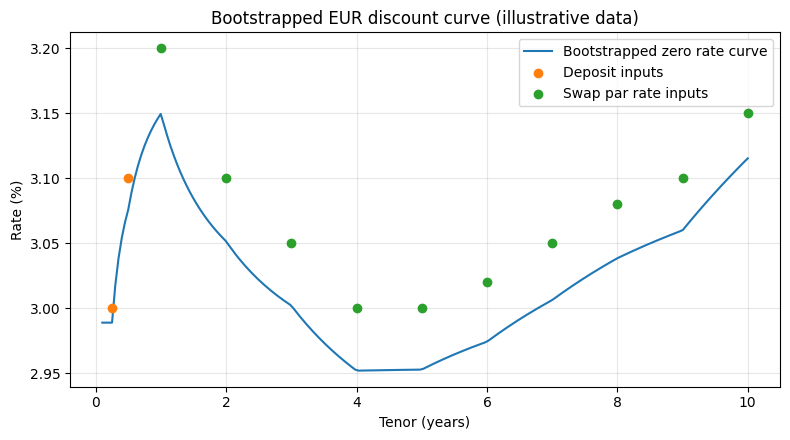

In [5]:
# Plot the bootstrapped curve: zero rates (smooth, interpolated) with the actual
# market pillars (deposits + swap par rates) marked separately, so the chart
# also documents which instrument drove which part of the curve.
t_grid = np.linspace(0.1, 10, 200)
zero_rates_grid = [curve.zero_rate(t) * 100 for t in t_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_grid, zero_rates_grid, label="Bootstrapped zero rate curve", color="tab:blue")
ax.scatter(deposit_tenors, [r * 100 for r in deposit_rates], color="tab:orange", zorder=5, label="Deposit inputs")
ax.scatter(swap_tenors, [r * 100 for r in swap_rates], color="tab:green", zorder=5, label="Swap par rate inputs")
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Rate (%)")
ax.set_title("Bootstrapped EUR discount curve (illustrative data)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Why the swap par rate points don't sit exactly on the zero-rate curve.**
This is expected, not a bug: the par swap rate at maturity $T$ is an
*annuity-weighted average* of the discount factors across **all** payment
dates up to $T$ — $K^*(T) = \dfrac{1 - P(0,T)}{\sum_i \delta_i P(0,T_i)}$ —
whereas the zero rate $z(T)$ only reflects the single discount factor
$P(0,T)$. They coincide at the very first pillar (a single payment, so no
averaging effect yet), and diverge more as $T$ grows and more prior years
enter the average, exactly as the chart shows.

## Vanilla interest rate swap class

In [6]:
class InterestRateSwap:
    """
    Vanilla fixed-for-floating interest rate swap, single-curve valuation.

    Under single-curve valuation, the floating leg reprices to par at every
    reset, so its PV telescopes down to N * (1 - P(0, maturity)) — no need to
    forecast individual forward rates explicitly.
    """

    def __init__(self, notional, fixed_rate, maturity, payment_freq=1):
        self.notional = notional
        self.fixed_rate = fixed_rate
        self.maturity = maturity
        self.payment_freq = payment_freq

    def _payment_times(self):
        delta = 1.0 / self.payment_freq
        n_payments = round(self.maturity * self.payment_freq)
        return [delta * i for i in range(1, n_payments + 1)], delta

    def fixed_leg_pv(self, curve):
        """PV of the fixed leg: N * K * sum_i(delta_i * P(0, T_i))."""
        payment_times, delta = self._payment_times()
        return self.notional * self.fixed_rate * sum(
            delta * curve.discount_factor(t) for t in payment_times
        )

    def floating_leg_pv(self, curve):
        """PV of the floating leg: N * (1 - P(0, maturity))."""
        return self.notional * (1 - curve.discount_factor(self.maturity))

    def npv_payer(self, curve):
        """NPV to the payer of fixed (pay fixed, receive floating)."""
        return self.floating_leg_pv(curve) - self.fixed_leg_pv(curve)

    def npv_receiver(self, curve):
        """NPV to the receiver of fixed (receive fixed, pay floating)."""
        return -self.npv_payer(curve)

    def par_rate(self, curve):
        """Fair fixed rate K* that makes NPV = 0 at inception."""
        payment_times, delta = self._payment_times()
        annuity = sum(delta * curve.discount_factor(t) for t in payment_times)
        return (1 - curve.discount_factor(self.maturity)) / annuity

In [7]:
swap_5y = InterestRateSwap(notional=10_000_000, fixed_rate=swap_rates[4], maturity=5)

print(f"Fixed leg PV    : {swap_5y.fixed_leg_pv(curve):,.2f}")
print(f"Floating leg PV : {swap_5y.floating_leg_pv(curve):,.2f}")
print(f"NPV (payer)     : {swap_5y.npv_payer(curve):,.2f}")
print(f"Par rate        : {swap_5y.par_rate(curve)*100:.4f}%  (market input was {swap_rates[4]*100:.4f}%)")

Fixed leg PV    : 1,372,513.98
Floating leg PV : 1,372,513.98
NPV (payer)     : 0.00
Par rate        : 3.0000%  (market input was 3.0000%)


## DV01 — parallel shock

In [8]:
def dv01(swap, curve, bp=1.0):
    """
    DV01 of the swap from the PAYER's perspective (pay fixed, receive floating):
    the change in NPV for a `bp` basis-point parallel UPWARD shift of the curve.

    Positive, because a fixed-rate payer benefits when rates rise (the floating
    leg they receive becomes more valuable, the fixed leg they owe becomes
    relatively cheaper). The receiver's DV01 is the negative of this value.
    """
    bumped_curve = curve.shift_parallel(bp)
    return swap.npv_payer(bumped_curve) - swap.npv_payer(curve)

In [9]:
swap_10y = InterestRateSwap(notional=10_000_000, fixed_rate=swap_rates[9], maturity=10)

for label, swap in [("5Y swap", swap_5y), ("10Y swap", swap_10y)]:
    payer_dv01 = dv01(swap, curve)
    print(f"{label} | payer DV01 = {payer_dv01:,.2f} per bp | receiver DV01 = {-payer_dv01:,.2f} per bp")

5Y swap | payer DV01 = 4,716.41 per bp | receiver DV01 = -4,716.41 per bp
10Y swap | payer DV01 = 8,723.43 per bp | receiver DV01 = -8,723.43 per bp


## Non-parallel stress — steepener / flattener

In [10]:
def curve_stress_shift(curve, short_bp, long_bp):
    """
    Apply a non-parallel stress to the curve: the zero-rate shift (in bp) is
    linearly interpolated between `short_bp` (at the shortest pillar) and
    `long_bp` (at the longest pillar). E.g. short_bp=-25, long_bp=+25 simulates
    a steepening of the curve; short_bp=+25, long_bp=-25 a flattening.
    """
    t_min, t_max = curve.tenors.min(), curve.tenors.max()

    def shift_fn(t):
        return np.interp(t, [t_min, t_max], [short_bp, long_bp])

    return curve.shift_custom(shift_fn)

In [11]:
steepened_curve = curve_stress_shift(curve, short_bp=-25, long_bp=+25)
flattened_curve = curve_stress_shift(curve, short_bp=+25, long_bp=-25)
parallel_up_curve = curve.shift_parallel(25)  # same average magnitude, for comparison

for label, shocked_curve in [
    ("Steepener (-25bp short / +25bp long)", steepened_curve),
    ("Flattener (+25bp short / -25bp long)", flattened_curve),
    ("Parallel +25bp (comparison)", parallel_up_curve),
]:
    npv_change_5y = swap_5y.npv_payer(shocked_curve) - swap_5y.npv_payer(curve)
    npv_change_10y = swap_10y.npv_payer(shocked_curve) - swap_10y.npv_payer(curve)
    print(f"{label:38} | 5Y payer NPV change: {npv_change_5y:>12,.0f} | 10Y payer NPV change: {npv_change_10y:>12,.0f}")

Steepener (-25bp short / +25bp long)   | 5Y payer NPV change:       -5,884 | 10Y payer NPV change:      192,789
Flattener (+25bp short / -25bp long)   | 5Y payer NPV change:        5,875 | 10Y payer NPV change:     -197,644
Parallel +25bp (comparison)            | 5Y payer NPV change:      117,222 | 10Y payer NPV change:      215,623


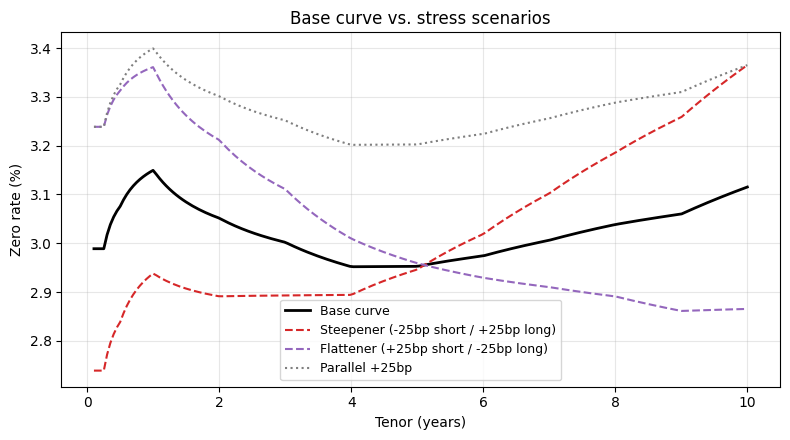

In [12]:
# Visualise the four curves together: this makes the difference between a
# parallel shift and a genuine change of curve SHAPE immediately obvious,
# which is the whole point of testing steepeners/flatteners separately.
t_grid = np.linspace(0.1, 10, 200)

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, c, style in [
    ("Base curve", curve, dict(color="black", linewidth=2)),
    ("Steepener (-25bp short / +25bp long)", steepened_curve, dict(color="tab:red", linestyle="--")),
    ("Flattener (+25bp short / -25bp long)", flattened_curve, dict(color="tab:purple", linestyle="--")),
    ("Parallel +25bp", parallel_up_curve, dict(color="tab:gray", linestyle=":")),
]:
    zero_rates_grid = [c.zero_rate(t) * 100 for t in t_grid]
    ax.plot(t_grid, zero_rates_grid, label=label, **style)

ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Zero rate (%)")
ax.set_title("Base curve vs. stress scenarios")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

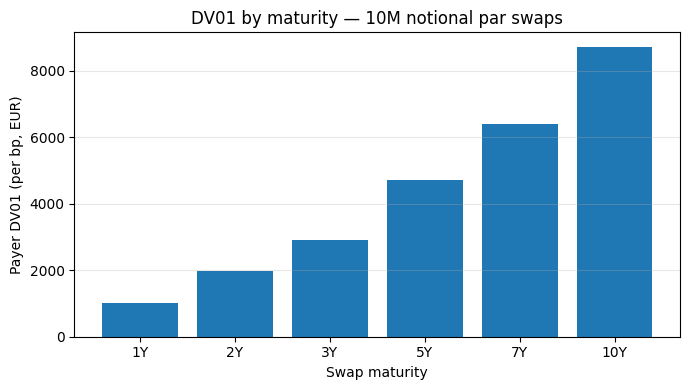

In [13]:
# DV01 across a range of maturities, to visualise how rate sensitivity grows
# with the swap's maturity (more, and more distant, cash flows exposed to the
# curve).
dv01_tenors = [1, 2, 3, 5, 7, 10]
dv01_values = [
    dv01(InterestRateSwap(notional=10_000_000, fixed_rate=swap_rates[t - 1], maturity=t), curve)
    for t in dv01_tenors
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(t) + "Y" for t in dv01_tenors], dv01_values, color="tab:blue")
ax.set_xlabel("Swap maturity")
ax.set_ylabel("Payer DV01 (per bp, EUR)")
ax.set_title("DV01 by maturity — 10M notional par swaps")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Validation & tests

In [14]:
def check(label, condition):
    assert condition, f"FAILED: {label}"
    print(f"OK   : {label}")


# 1. Self-consistency of the bootstrap: the par rate of a swap priced off the
#    curve, for each maturity used to BUILD that curve, must recover the
#    original market input rate almost exactly.
for T, K_market in zip(swap_tenors, swap_rates):
    test_swap = InterestRateSwap(notional=1, fixed_rate=K_market, maturity=T)
    K_recovered = test_swap.par_rate(curve)
    check(f"Bootstrap self-consistency at T={T}Y", abs(K_recovered - K_market) < 1e-10)

# 2. A swap struck at its own par rate must have NPV = 0 (both directions).
check("NPV(payer) = 0 at par rate", abs(swap_5y.npv_payer(curve)) < 1e-6)
check("NPV(receiver) = 0 at par rate", abs(swap_5y.npv_receiver(curve)) < 1e-6)

# 3. DV01 sign: payer benefits from rising rates (positive DV01); receiver DV01
#    is exactly the negative of the payer's.
payer_dv01_5y = dv01(swap_5y, curve)
check("Payer DV01 is positive", payer_dv01_5y > 0)
check("Receiver DV01 = -Payer DV01", abs(dv01(swap_5y, curve) + (-payer_dv01_5y)) < 1e-8)

# 4. A longer-maturity swap must have a larger (in absolute value) DV01 than a
#    shorter one of the same notional -- more cash flows exposed to the curve.
check("10Y swap DV01 > 5Y swap DV01 (larger duration)", dv01(swap_10y, curve) > dv01(swap_5y, curve))

# 5. The model must be sensitive to curve SHAPE, not just level: a steepener and
#    a flattener of the same magnitude must produce different NPV impacts on a
#    swap whose cash flows are concentrated at a single maturity.
steepener_impact = swap_10y.npv_payer(steepened_curve) - swap_10y.npv_payer(curve)
flattener_impact = swap_10y.npv_payer(flattened_curve) - swap_10y.npv_payer(curve)
check("Steepener and flattener produce different NPV impact (curve shape risk)", abs(steepener_impact - flattener_impact) > 1.0)

print("\nAll checks passed.")

OK   : Bootstrap self-consistency at T=1Y
OK   : Bootstrap self-consistency at T=2Y
OK   : Bootstrap self-consistency at T=3Y
OK   : Bootstrap self-consistency at T=4Y
OK   : Bootstrap self-consistency at T=5Y
OK   : Bootstrap self-consistency at T=6Y
OK   : Bootstrap self-consistency at T=7Y
OK   : Bootstrap self-consistency at T=8Y
OK   : Bootstrap self-consistency at T=9Y
OK   : Bootstrap self-consistency at T=10Y
OK   : NPV(payer) = 0 at par rate
OK   : NPV(receiver) = 0 at par rate
OK   : Payer DV01 is positive
OK   : Receiver DV01 = -Payer DV01
OK   : 10Y swap DV01 > 5Y swap DV01 (larger duration)
OK   : Steepener and flattener produce different NPV impact (curve shape risk)

All checks passed.


## Known limitations

- **Single-curve framework**: discounting and forwarding use the same curve.
  Real desks have used a dual-curve framework (OIS discounting, Euribor
  forwarding) since the 2008 Libor-OIS spread blowout — see the structuring
  prep document, Q131-132 (cross-currency basis) for the related concept.
- **Consecutive annual swap tenors only**: the bootstrap avoids needing an
  interpolation assumption between market pillars by using 1Y, 2Y, ..., 10Y
  rates. A real curve is built from sparser market tenors (2Y, 3Y, 5Y, 7Y,
  10Y) and needs an explicit interpolation choice (e.g. log-linear on
  discount factors, or a spline) applied *during* the bootstrap itself.
- **No day-count conventions**: all periods are treated as exact fractions of
  a year (ACT/365-style simplification); real swaps use conventions like
  30/360 or ACT/360 depending on the currency and leg.
- **Annual fixed-leg frequency only** in the examples above, though the
  `payment_freq` parameter supports other frequencies (e.g. semi-annual).
- **DV01 only for a parallel shock and a simple linear steepener/flattener**:
  a real risk system would report DV01 per curve *bucket* (cf. the "vega
  bucket" concept in the structuring document, Q185, applied here to rate
  buckets instead of vol buckets) rather than a single aggregate number.